LABORATORIO 3 REGRESION POLINOMICA

In [247]:
# Importando librerias
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [248]:
# extraendo los datos
data = pd.read_csv('Salario_2025_1992.csv', delimiter=',')
# X = año
x = data['year']
# Y = salario mensual
y = data['monthly_wage']

In [249]:
def graficar(x, y):
    
    plt.plot(x, y, 'ro', ms=15, mec='k')
    plt.ylabel('Salario mensual')
    plt.xlabel('Año')

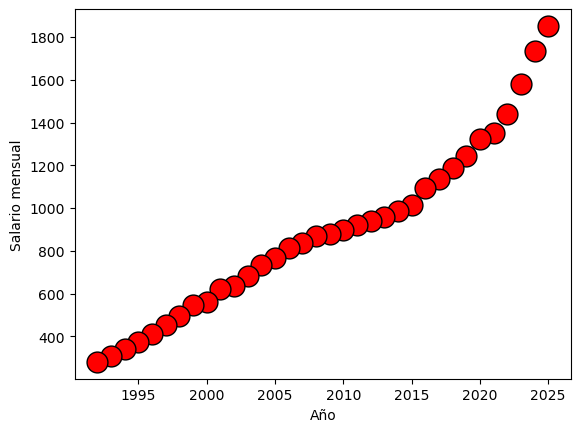

In [250]:
# visualizar los datos
graficar(x,y)

CONCATENANDO VARIABLES HASTA DE TERCER GRADO

In [251]:
x = pd.concat([x, x**2 ,x**3], axis=1)
x.shape

(34, 3)

In [252]:
print(x)
x.shape

    year     year        year
0   2025  4100625  8303765625
1   2024  4096576  8291469824
2   2023  4092529  8279186167
3   2022  4088484  8266914648
4   2021  4084441  8254655261
5   2020  4080400  8242408000
6   2019  4076361  8230172859
7   2018  4072324  8217949832
8   2017  4068289  8205738913
9   2016  4064256  8193540096
10  2015  4060225  8181353375
11  2014  4056196  8169178744
12  2013  4052169  8157016197
13  2012  4048144  8144865728
14  2011  4044121  8132727331
15  2010  4040100  8120601000
16  2009  4036081  8108486729
17  2008  4032064  8096384512
18  2007  4028049  8084294343
19  2006  4024036  8072216216
20  2005  4020025  8060150125
21  2004  4016016  8048096064
22  2003  4012009  8036054027
23  2002  4008004  8024024008
24  2001  4004001  8012006001
25  2000  4000000  8000000000
26  1999  3996001  7988005999
27  1998  3992004  7976023992
28  1997  3988009  7964053973
29  1996  3984016  7952095936
30  1995  3980025  7940149875
31  1994  3976036  7928215784
32  1993  

(34, 3)

NORMALIZACION DE LOS DATOS

In [253]:
def normalizacion(x):
    x_norm = np.array(x.shape)
    miu = np.zeros(x.shape[1])
    sigma = np.zeros(x.shape[1])

    miu = np.mean(x , axis=0)
    sigma = np.std(x , axis=0)
    x_norm = (x - miu) / sigma
    
    return x_norm, miu, sigma

In [254]:
x, miu, sigma = normalizacion(x)
print('la media es: ',miu)
print('la sigmoide es: ',sigma)

la media es:  year    2.008500e+03
year    4.034168e+06
year    8.103014e+09
dtype: float64
la sigmoide es:  year    9.810708e+00
year    3.940971e+04
year    1.187341e+08
dtype: float64


In [255]:
# concatenando la columna de unos
m = y.size
x = np.concatenate([np.ones((m,1)), x], axis=1)
print(x)

[[ 1.          1.68183573  1.68629763  1.69076513]
 [ 1.          1.57990629  1.58355646  1.58720771]
 [ 1.          1.47797686  1.48086603  1.48375258]
 [ 1.          1.37604742  1.37822635  1.38039968]
 [ 1.          1.27411798  1.27563741  1.27714895]
 [ 1.          1.17218854  1.17309923  1.17400035]
 [ 1.          1.0702591   1.0706118   1.07095383]
 [ 1.          0.96832966  0.96817511  0.96800933]
 [ 1.          0.86640023  0.86578918  0.86516681]
 [ 1.          0.76447079  0.76345399  0.76242622]
 [ 1.          0.66254135  0.66116955  0.6597875 ]
 [ 1.          0.56061191  0.55893586  0.5572506 ]
 [ 1.          0.45868247  0.45675292  0.45481548]
 [ 1.          0.35675303  0.35462073  0.35248208]
 [ 1.          0.2548236   0.25253929  0.25025035]
 [ 1.          0.15289416  0.15050859  0.14812025]
 [ 1.          0.05096472  0.04852865  0.04609171]
 [ 1.         -0.05096472 -0.05340055 -0.0558353 ]
 [ 1.         -0.15289416 -0.15527899 -0.15766084]
 [ 1.         -0.2548236  -0.25

FUNCION DE COSTO

In [256]:
def costo(x, y, theta):
    m = y.size
    J = 0

    J = (1 / (2 * m)) * np.sum(np.square(np.dot(x , theta) - y))

    return J

DESCENSO POR EL GRADIENTE

In [257]:
def gradiente(x , y, theta, alpha, num_iters):
    m = y.size
    J_history = []
    theta = theta.copy()

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(x,theta)- y).dot(x)
        J_history.append(costo(x, y, theta))

    return theta, J_history

SELECCIONANDO VALORES DE PRUEBA

In [258]:
alpha = 0.001
num_iters = 15000
theta = np.zeros(4)

theta, J_history = gradiente(x, y, theta, alpha, num_iters)

print('los valores de theta son: ',theta)

los valores de theta son:  [890.28296499 128.91422184 130.67998142 132.45053762]


Text(0, 0.5, 'Valores del costo')

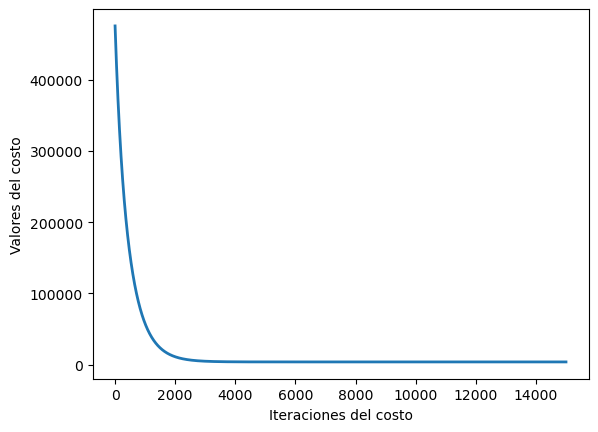

In [259]:
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel("Iteraciones del costo")
plt.ylabel("Valores del costo")

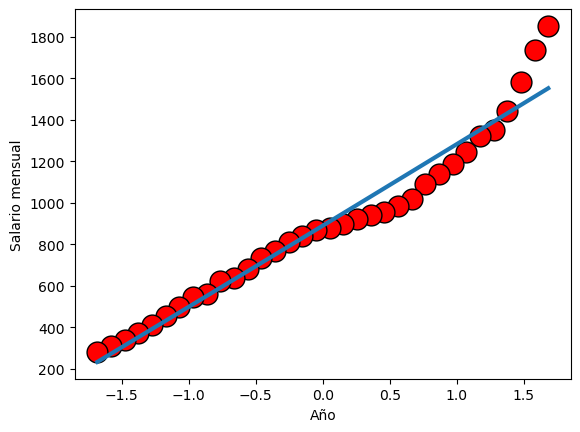

In [262]:
graficar(x[:,1], y)
plt.plot(x[:,1], np.dot(x,theta), lw=3)

In [270]:
x1 = np.array([2025, 2025, 2025])
x1 = (x1 - miu) / sigma
x1 = np.append(1 , x1)

y_pred = np.dot(x1 , theta)
print("El salario mensual es: ",y_pred)

El salario mensual es:  1303376990.279283


ECUACION DE LA NORMAL

In [267]:
def ecNormal(x,y):
    theta = np.zeros(x.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(x.T, x)),x.T),y) 

    return theta

In [268]:
theta = ecNormal(x, y)
print("valores de theta:", theta)

valores de theta: [ 8.90283235e+02  9.43452614e+06 -1.88937067e+07  9.45961756e+06]


In [ ]:
# prediciendo los con los mismo datos
x1 = np.array([1, 2025, 2025, 2025])
resultado = np.dot(theta,x1)

print("El resultado es:",resultado)

El resultado es: 885828.8650665283


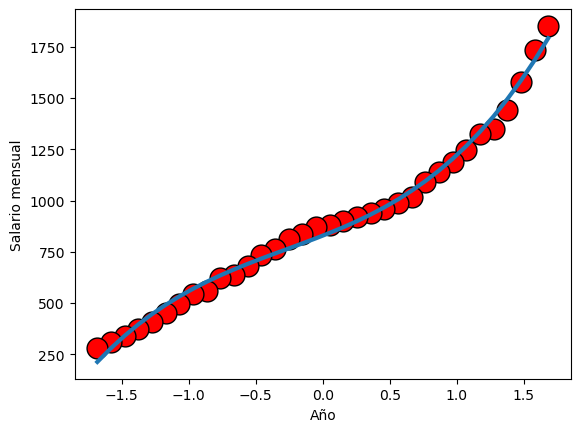

In [271]:
graficar(x[:,1], y)
plt.plot(x[:,1], np.dot(x,theta), lw=3)

como podemos apreciar la ecuacion de la normal es mucho mas precisa en este caso